# Imports

In [14]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import math
from pandas import DataFrame, Series

# Datos de entrada

In [15]:
difusividad = 1 # [cm^2/s]
t = 1 #[s]
L = 1 # [cm]
terminos = 5 #Términos de la sumatoria
muestras = 7 #Número de pares de datos de $\Delta$p

# Funciones

In [16]:
def lambda_n(n):
    lam = n * np.pi / L
    return lam

In [17]:
def Bn(n,p1,p2):
    B = B = (p1 * (np.cos(n*np.pi) - 1)
     - 2*(p2-p1)*(L-1)*np.cos(n*np.pi)) / (n*np.pi)
    return B

In [18]:
def p(x,t, p1, p2):
    sumatoria = 0
    for i in range(1, terminos + 1):
        sumatoria += Bn(i,p1,p2) * np.sin(lambda_n(i) * x) * math.exp(- (lambda_n(i) ** 2 * difusividad * t))
    return sumatoria

# Generación de n pares de $\Delta$p

In [19]:
rng = np.random.default_rng(seed = 123)  
p1 = np.zeros(muestras)
p2 = np.zeros(muestras)
for i in range(muestras):
    p1[i] = rng.integers(3000, 4000)
    p2[i] = p1[i] - rng.integers(1,500)
    
data = pd.DataFrame(index = np.arange(muestras))
data["P1"] = p1
data["P2"] = p2
data[r"$\Delta$p"] = p1 - p2
data = data.sort_values(by = r"$\Delta$p")
data.index = np.arange(muestras)

# Resultados

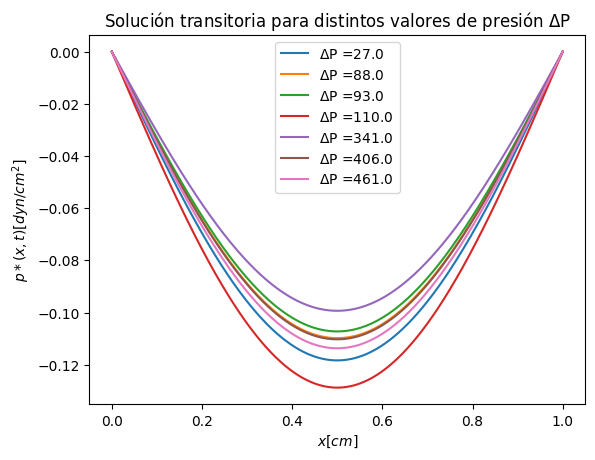

In [20]:
for j in range(muestras):
    
    x = np.linspace(0, L, 1000)
    
    presion_1 = data.loc[j]["P1"]
    presion_2 = data.loc[j]["P2"]
    
    presion = np.zeros_like(x)
    
    for i in range(len(x)):
        presion[i] = p(x[i], t, presion_1, presion_2)
    
    plt.plot(x, presion, label = r"$\Delta$P ="f"{presion_1-presion_2}")
    plt.title(r"Solución transitoria para distintos valores de presión $\Delta$P")
    plt.xlabel("$x [cm]$")
    plt.ylabel("$p*(x,t) [dyn/cm^{2}]$")
    plt.legend()

In [21]:
data

,P1,P2,$\Delta$p
0,3592.0,3565.0,27.0
1,3333.0,3245.0,88.0
2,3255.0,3162.0,93.0
3,3909.0,3799.0,110.0
4,3015.0,2674.0,341.0
5,3347.0,2941.0,406.0
6,3451.0,2990.0,461.0
